<a href="https://colab.research.google.com/github/aruna-31/Deep-Learning-practice-and-basic-projects/blob/main/DL_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q opencv-python torch torchvision scikit-learn

In [ ]:
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import numpy as np

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def extract_frames(video_path, interval=0.5):
    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    duration = total / fps

    frames = []
    times = []

    t = 0

    while t < duration:
        cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000)
        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
            times.append(t)

        t += interval

    cap.release()

    return frames, times

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
video_path = '/content/drive/MyDrive/video.mp4'

In [ ]:
import os
print(os.path.exists(video_path))  # Should print: True

True


In [ ]:
frames, times = extract_frames(video_path)

print("Frames extracted:", len(frames))
print("Duration:", round(times[-1], 2), "seconds")

Frames extracted: 157
Duration: 78.0 seconds


In [ ]:
def extract_features(frames):
    features = []

    with torch.no_grad():
        for frame in frames:
            x = transform(frame).unsqueeze(0).to(device)
            feature = cnn(x)
            features.append(feature.cpu())

    return torch.cat(features)

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform ready")

Transform ready


In [ ]:
from torchvision import models
import torch.nn as nn

cnn = models.resnet18(weights="DEFAULT")
cnn.fc = nn.Identity()

cnn = cnn.to(device)
cnn.eval()

print("CNN ready")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


CNN ready


In [ ]:
features = extract_features(frames)

print("Feature shape:", features.shape)

Feature shape: torch.Size([157, 512])


In [ ]:
sequence_length = 16

sequences = []

for i in range(len(features) - sequence_length + 1):
    sequences.append(features[i:i+sequence_length])

sequences = torch.stack(sequences)

print("Sequence shape:", sequences.shape)

Sequence shape: torch.Size([142, 16, 512])


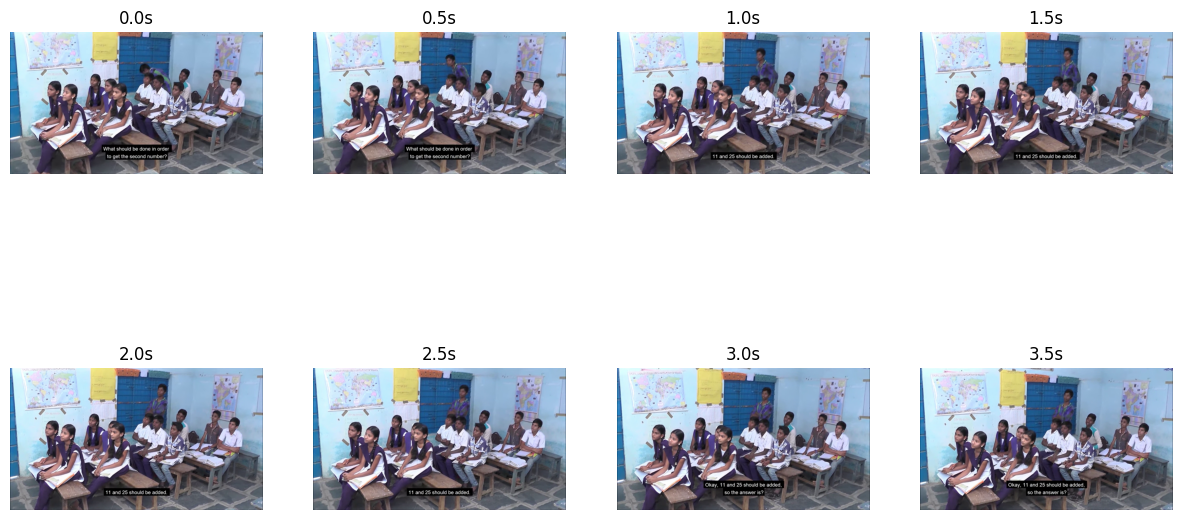

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i in range(min(8, len(frames))):
    plt.subplot(2, 4, i+1)
    plt.imshow(frames[i])
    plt.title(f"{times[i]:.1f}s")
    plt.axis("off")

plt.show()

In [ ]:
cnn = models.resnet18(weights="DEFAULT")

cnn.fc = nn.Identity()

cnn = cnn.to(device)
cnn.eval()

print("CNN loaded")

CNN loaded


In [ ]:
classes = [
    "Looking_Toward_Instruction",
    "Reading",
    "Writing",
    "Peer_Interaction",
    "Looking_Away"
]

for i, name in enumerate(classes):
    print(i, "=", name)

0 = Looking_Toward_Instruction
1 = Reading
2 = Writing
3 = Peer_Interaction
4 = Looking_Away


In [ ]:
block_size = 5

blocks = []

for start in np.arange(0, 78, block_size):
    end = min(start + block_size, 78)
    blocks.append((round(start, 1), round(end, 1)))

print("Number of blocks:", len(blocks))

for i, (start, end) in enumerate(blocks):
    print(i, f"{start}s - {end}s")

Number of blocks: 16
0 0s - 5s
1 5s - 10s
2 10s - 15s
3 15s - 20s
4 20s - 25s
5 25s - 30s
6 30s - 35s
7 35s - 40s
8 40s - 45s
9 45s - 50s
10 50s - 55s
11 55s - 60s
12 60s - 65s
13 65s - 70s
14 70s - 75s
15 75s - 78s


In [ ]:
def show_block(block_number):

    start, end = blocks[block_number]

    selected = [
        i for i, t in enumerate(times)
        if start <= t < end
    ]

    plt.figure(figsize=(15, 6))

    for j, idx in enumerate(selected[:6]):
        plt.subplot(2, 3, j + 1)
        plt.imshow(frames[idx])
        plt.title(f"{times[idx]:.1f}s")
        plt.axis("off")

    plt.suptitle(f"Video segment: {start}s - {end}s")
    plt.tight_layout()
    plt.show()

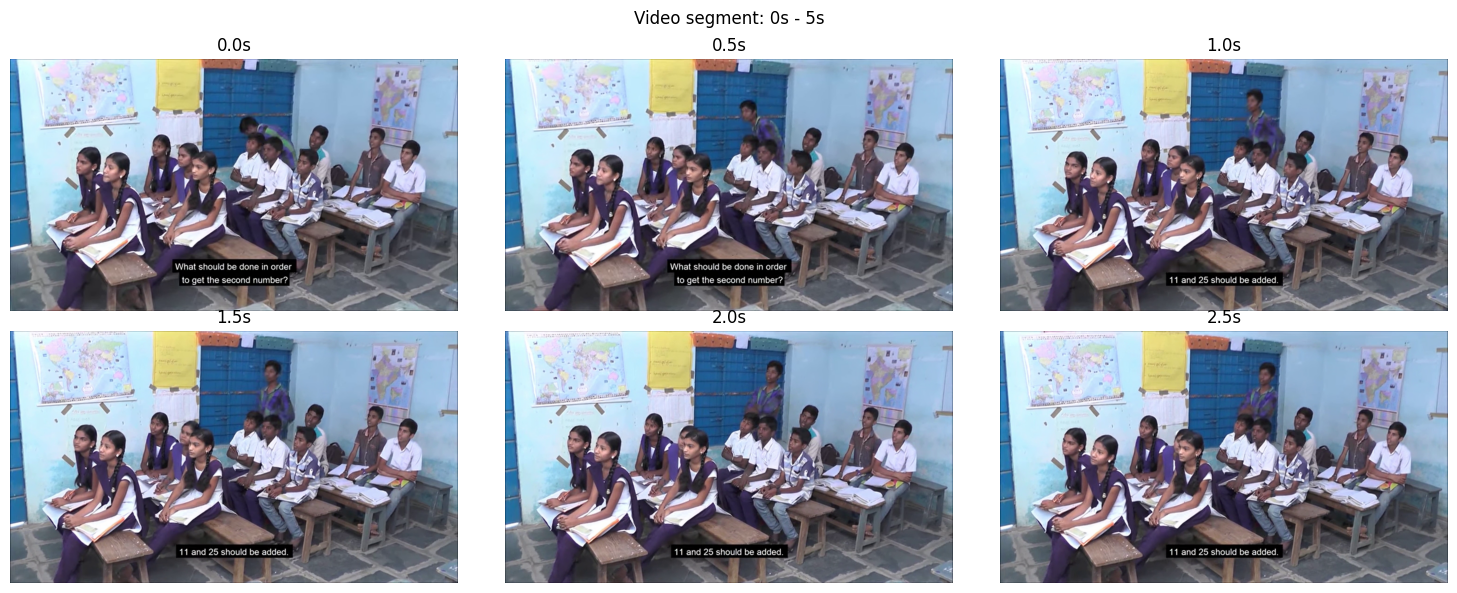

In [ ]:
show_block(0)

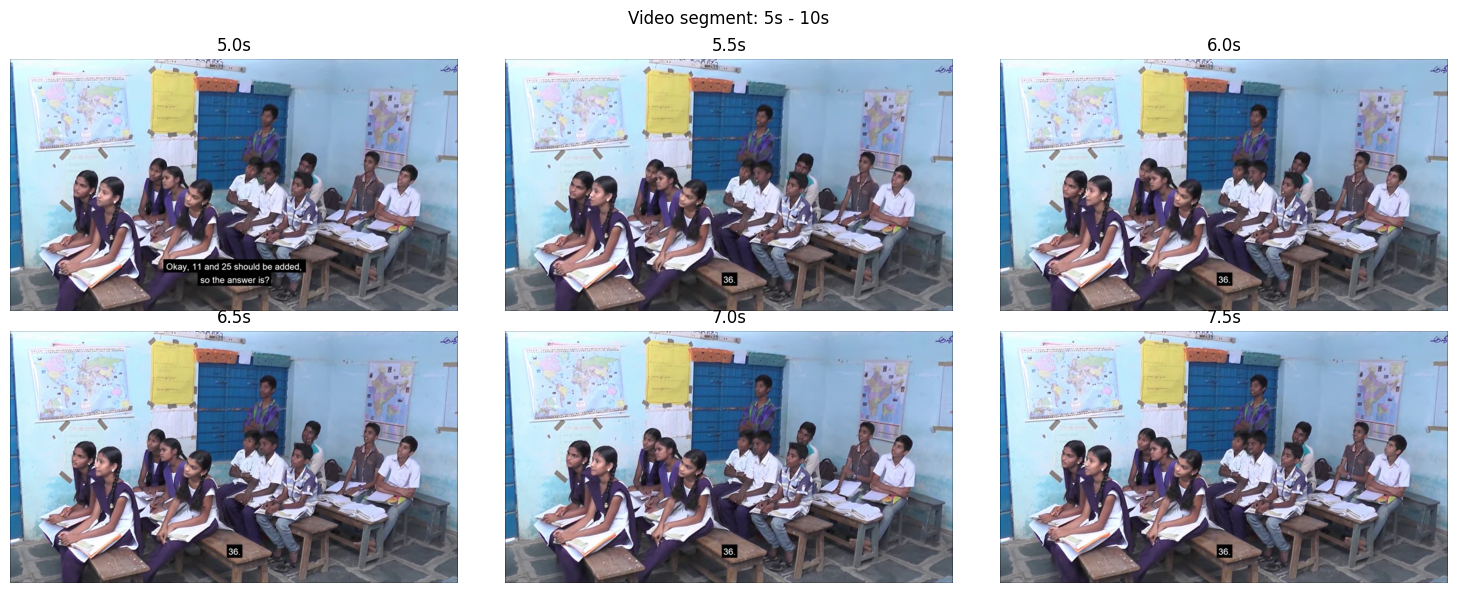

In [ ]:
show_block(1)

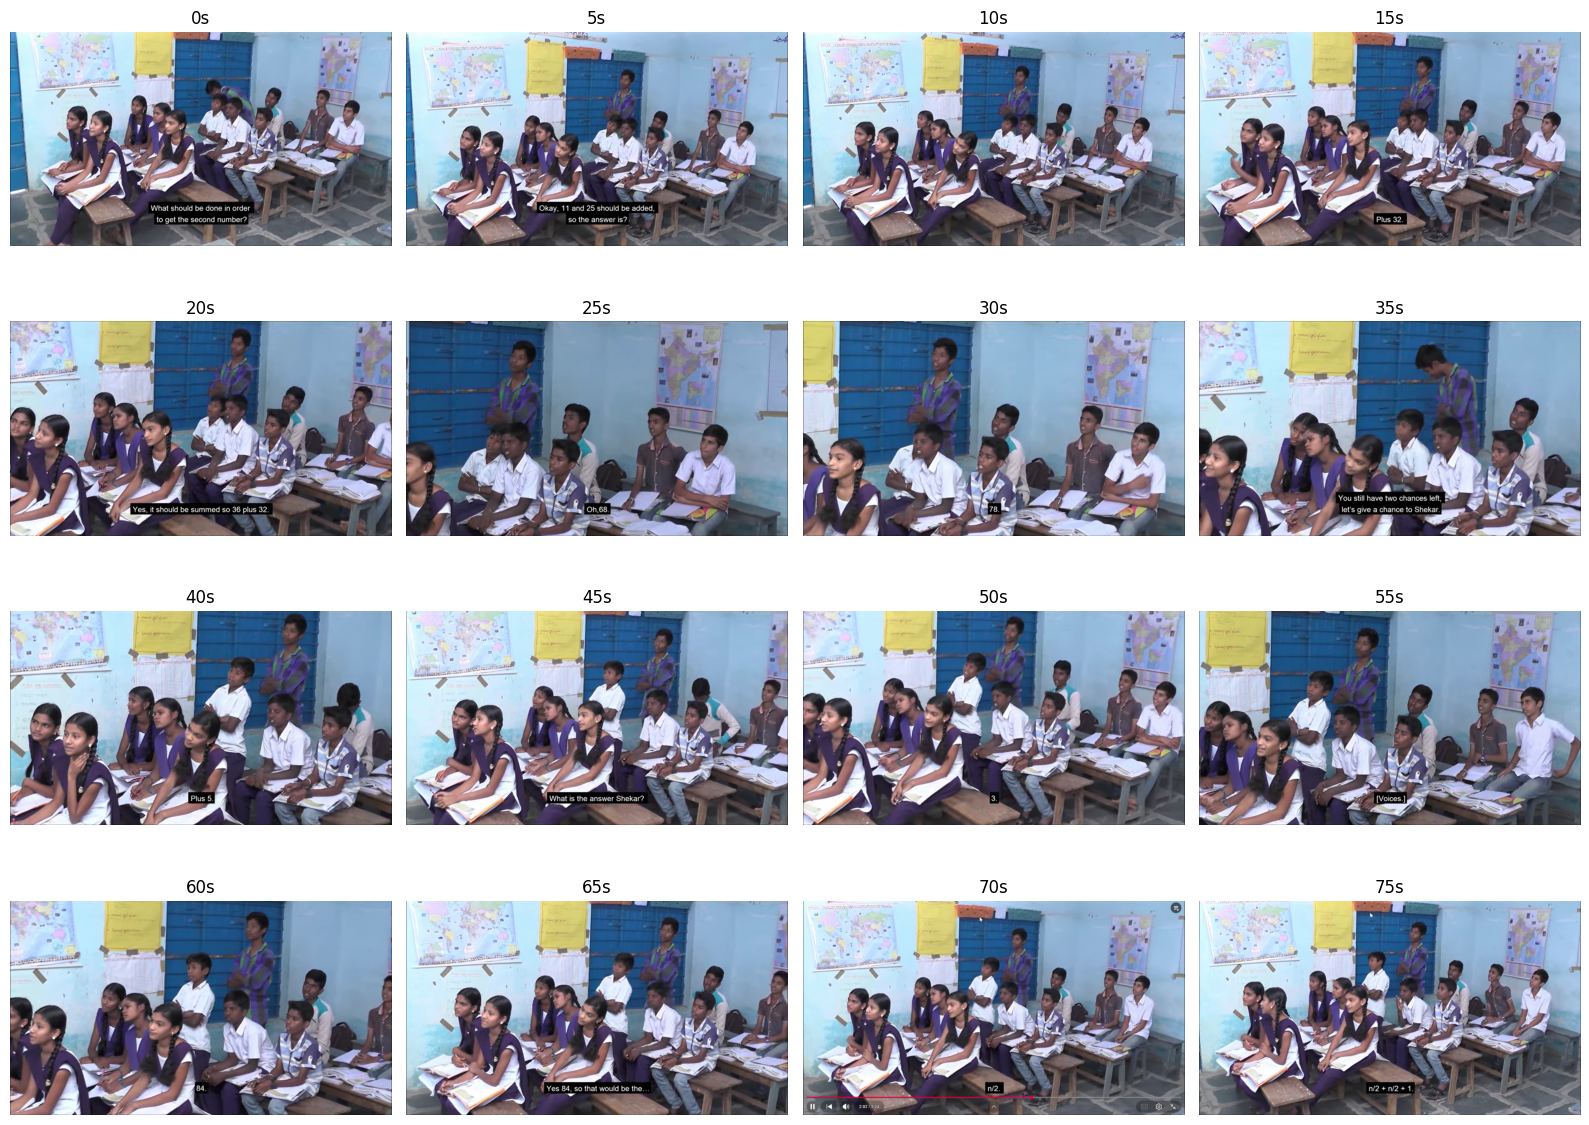

In [ ]:
import matplotlib.pyplot as plt

# Show one frame every 5 seconds
selected = []

for t in np.arange(0, 78, 5):
    idx = min(range(len(times)), key=lambda i: abs(times[i] - t))
    selected.append(idx)

plt.figure(figsize=(16, 12))

for j, idx in enumerate(selected):
    plt.subplot(4, 4, j + 1)
    plt.imshow(frames[idx])
    plt.title(f"{times[idx]:.0f}s")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Enter 16 labels separated by spaces")
print("0 = Looking Toward Instruction")
print("1 = Reading")
print("2 = Writing")
print("3 = Peer Interaction")
print("4 = Looking Away")

user_input = input("Labels: ")

block_labels = [int(x) for x in user_input.split()]

print("Labels entered:", block_labels)
print("Number of labels:", len(block_labels))

Enter 16 labels separated by spaces
0 = Looking Toward Instruction
1 = Reading
2 = Writing
3 = Peer Interaction
4 = Looking Away
Labels: 0 0 2 2 1 1 0 3 3 2 2 0 4 4 0 2
Labels entered: [0, 0, 2, 2, 1, 1, 0, 3, 3, 2, 2, 0, 4, 4, 0, 2]
Number of labels: 16


In [ ]:
if len(block_labels) != len(blocks):
    print("ERROR: Need", len(blocks), "labels, but got", len(block_labels))
else:
    sequence_times = []

    for i in range(len(sequences)):
        start_time = times[i]
        end_time = times[i + sequence_length - 1]
        center_time = (start_time + end_time) / 2
        sequence_times.append(center_time)

    sequence_labels = []

    for t in sequence_times:
        block_index = min(
            int(t // block_size),
            len(block_labels) - 1
        )
        sequence_labels.append(block_labels[block_index])

    sequence_labels = torch.tensor(sequence_labels)

    print("Sequences:", len(sequences))
    print("Labels:", len(sequence_labels))

Sequences: 142
Labels: 142


In [ ]:
from collections import Counter

counts = Counter(sequence_labels.tolist())

for label, count in sorted(counts.items()):
    print(classes[label], ":", count)

Looking_Toward_Instruction : 42
Reading : 20
Writing : 40
Peer_Interaction : 20
Looking_Away : 20


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    sequences,
    sequence_labels,
    test_size=0.2,
    random_state=42,
    stratify=sequence_labels
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTrain labels:")
print(torch.bincount(y_train, minlength=5))

print("\nTest labels:")
print(torch.bincount(y_test, minlength=5))

Training: torch.Size([113, 16, 512])
Testing : torch.Size([29, 16, 512])

Train labels:
tensor([33, 16, 32, 16, 16])

Test labels:
tensor([9, 4, 8, 4, 4])


In [ ]:
class TemporalModel(nn.Module):

    def __init__(self, model_type, input_size=512,
                 hidden_size=128, num_classes=5):

        super().__init__()

        self.model_type = model_type

        if model_type == "RNN":
            self.temporal = nn.RNN(
                input_size,
                hidden_size,
                batch_first=True
            )

        elif model_type == "LSTM":
            self.temporal = nn.LSTM(
                input_size,
                hidden_size,
                batch_first=True
            )

        elif model_type == "GRU":
            self.temporal = nn.GRU(
                input_size,
                hidden_size,
                batch_first=True
            )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        output, _ = self.temporal(x)

        last_output = output[:, -1, :]

        return self.fc(last_output)

In [ ]:
def train_model(model, X_train, y_train, epochs=30):

    model = model.to(device)

    X_train = X_train.to(device)
    y_train = y_train.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        output = model(X_train)

        loss = criterion(output, y_train)

        loss.backward()

        optimizer.step()

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} "
                f"Loss: {loss.item():.4f}"
            )

    return model

In [ ]:
rnn_model = TemporalModel("RNN")

rnn_model = train_model(
    rnn_model,
    X_train,
    y_train
)

Epoch 5/30 Loss: 1.2094
Epoch 10/30 Loss: 0.8743
Epoch 15/30 Loss: 0.6177
Epoch 20/30 Loss: 0.4217
Epoch 25/30 Loss: 0.2774
Epoch 30/30 Loss: 0.1804


In [ ]:
lstm_model = TemporalModel("LSTM")

lstm_model = train_model(
    lstm_model,
    X_train,
    y_train
)

Epoch 5/30 Loss: 1.1922
Epoch 10/30 Loss: 0.7637
Epoch 15/30 Loss: 0.4754
Epoch 20/30 Loss: 0.3042
Epoch 25/30 Loss: 0.1809
Epoch 30/30 Loss: 0.1128


In [ ]:
gru_model = TemporalModel("GRU")

gru_model = train_model(
    gru_model,
    X_train,
    y_train
)

Epoch 5/30 Loss: 1.1921
Epoch 10/30 Loss: 0.8799
Epoch 15/30 Loss: 0.6220
Epoch 20/30 Loss: 0.4151
Epoch 25/30 Loss: 0.2673
Epoch 30/30 Loss: 0.1703


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test, y_test):

    model.eval()

    with torch.no_grad():
        output = model(X_test.to(device))
        predictions = torch.argmax(output, dim=1).cpu().numpy()

    actual = y_test.numpy()

    accuracy = accuracy_score(actual, predictions)

    precision = precision_score(
        actual, predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        actual, predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        actual, predictions,
        average="macro",
        zero_division=0
    )

    return accuracy, precision, recall, f1

In [ ]:
models_to_test = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

results = {}

for name, model in models_to_test.items():

    acc, precision, recall, f1 = evaluate_model(
        model,
        X_test,
        y_test
    )

    results[name] = [acc, precision, recall, f1]

    print(f"\n{name}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))


RNN
Accuracy : 0.8966
Precision: 0.9378
Recall   : 0.8778
F1 Score : 0.8995

LSTM
Accuracy : 0.9655
Precision: 0.98
Recall   : 0.95
F1 Score : 0.9609

GRU
Accuracy : 0.9655
Precision: 0.9778
Recall   : 0.9778
F1 Score : 0.9765


In [ ]:
print("TRAINING LABELS")
print(torch.bincount(y_train, minlength=5))

print("\nTEST LABELS")
print(torch.bincount(y_test, minlength=5))

print("\nActual test labels:")
print(y_test.tolist())

TRAINING LABELS
tensor([33, 16, 32, 16, 16])

TEST LABELS
tensor([9, 4, 8, 4, 4])

Actual test labels:
[3, 3, 2, 2, 0, 2, 2, 2, 0, 1, 0, 3, 1, 0, 4, 2, 2, 4, 0, 1, 3, 1, 4, 4, 2, 0, 0, 0, 0]


In [ ]:
for name, model in models_to_test.items():

    model.eval()

    with torch.no_grad():
        output = model(X_test.to(device))
        predictions = torch.argmax(output, dim=1).cpu()

    print("\n", name)
    print("Predicted:", predictions.tolist())
    print("Actual   :", y_test.tolist())


 RNN
Predicted: [3, 3, 2, 2, 0, 2, 2, 2, 0, 1, 0, 3, 1, 0, 4, 2, 2, 4, 0, 1, 0, 1, 0, 4, 2, 0, 0, 2, 0]
Actual   : [3, 3, 2, 2, 0, 2, 2, 2, 0, 1, 0, 3, 1, 0, 4, 2, 2, 4, 0, 1, 3, 1, 4, 4, 2, 0, 0, 0, 0]

 LSTM
Predicted: [3, 3, 2, 2, 0, 2, 2, 2, 0, 1, 0, 3, 1, 0, 4, 2, 2, 4, 0, 1, 3, 1, 0, 4, 2, 0, 0, 0, 0]
Actual   : [3, 3, 2, 2, 0, 2, 2, 2, 0, 1, 0, 3, 1, 0, 4, 2, 2, 4, 0, 1, 3, 1, 4, 4, 2, 0, 0, 0, 0]

 GRU
Predicted: [3, 3, 2, 2, 0, 2, 2, 2, 0, 1, 0, 3, 1, 0, 4, 2, 2, 4, 0, 1, 3, 1, 4, 4, 2, 0, 0, 2, 0]
Actual   : [3, 3, 2, 2, 0, 2, 2, 2, 0, 1, 0, 3, 1, 0, 4, 2, 2, 4, 0, 1, 3, 1, 4, 4, 2, 0, 0, 0, 0]


In [ ]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1"]
).T

results_df

,Accuracy,Precision,Recall,F1
RNN,0.896552,0.937778,0.877778,0.899513
LSTM,0.965517,0.980000,0.950000,0.960902
GRU,0.965517,0.977778,0.977778,0.976471


GRU is the best

In [ ]:
best_model = gru_model
best_model.eval()

with torch.no_grad():
    outputs = best_model(sequences.to(device))

    probabilities = torch.softmax(outputs, dim=1)

    predictions = torch.argmax(
        probabilities, dim=1
    ).cpu().numpy()

    confidences = torch.max(
        probabilities, dim=1
    ).values.cpu().numpy()

print("Predictions generated:", len(predictions))

Predictions generated: 142


In [ ]:
import cv2
import numpy as np

# Use GRU as our best prototype model
best_model = gru_model
best_model.eval()

# Generate predictions + confidence
with torch.no_grad():
    outputs = best_model(sequences.to(device))
    probabilities = torch.softmax(outputs, dim=1)

    predictions = torch.argmax(
        probabilities, dim=1
    ).cpu().numpy()

    confidences = torch.max(
        probabilities, dim=1
    ).values.cpu().numpy()

# Open original video
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

output_path = "/content/PS1_predicted_classroom.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

frame_number = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    current_time = frame_number / fps

    # Find nearest temporal prediction
    nearest_index = np.argmin(
        np.abs(np.array(sequence_times) - current_time)
    )

    predicted_class = predictions[nearest_index]
    confidence = confidences[nearest_index]

    label = classes[predicted_class]

    # Display information
    text1 = f"Behaviour: {label}"
    text2 = f"Confidence: {confidence * 100:.1f}%"
    text3 = f"Time: {current_time:.1f}s"

    cv2.rectangle(
        frame,
        (20, 20),
        (650, 135),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        frame,
        text1,
        (35, 55),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.putText(
        frame,
        text2,
        (35, 90),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    cv2.putText(
        frame,
        text3,
        (35, 120),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2
    )

    out.write(frame)

    frame_number += 1

cap.release()
out.release()

print("Video created successfully!")
print("Saved at:", output_path)

Video created successfully!
Saved at: /content/PS1_predicted_classroom.mp4


In [ ]:
from IPython.display import Video

Video(
    "/content/PS1_predicted_classroom.mp4",
    embed=True
)

In [ ]:
from google.colab import files

files.download("/content/PS1_final.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ffmpeg -y -i /content/PS1_predicted_classroom.mp4 \
-c:v libx264 -pix_fmt yuv420p \
-c:a aac /content/PS1_final.mp4

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [ ]:
from IPython.display import Video, display

display(
    Video(
        "/content/PS1_final.mp4",
        embed=True
    )
)